In [ ]:
# CatBoost Classification Model

#This component applies the CatBoost machine learning algorithm for heart disease
#prediction using the Heart Disease dataset. Medical attributes such as age,
#cholesterol level, blood pressure, and heart rate are used as input features,
#while the target variable represents the presence or absence of heart disease.

#CatBoost is a supervised machine learning algorithm based on gradient boosting
#decision trees. It is selected because it performs well on structured tabular
#data, reduces overfitting, and typically achieves higher accuracy compared to
#traditional classifiers such as Logistic Regression.

In [11]:
# Install CatBoost library
!pip install catboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Import core libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load dataset 
data = pd.read_csv('heart.csv')

print("Dataset loaded successfully")
print(data.shape)
data.head()

Dataset loaded successfully
(918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
### Dataset Description

# The dataset used in this project is the **Heart Disease Dataset**, which contains medical records of patients used to predict the presence of heart disease. The dataset includes several clinical and physiological attributes such as age, resting blood pressure, cholesterol level, maximum heart rate achieved, and chest pain type.

# The dataset consists of **918 patient records** and **12 attributes**, where **11 features** are used as input variables and **1 target variable (HeartDisease)** indicates whether the patient has heart disease or not.

# The target variable **HeartDisease** is binary:
# - **0** – No heart disease
# - **1** – Presence of heart disease

# The dataset contains a mix of **numerical features** (such as Age, Cholesterol, RestingBP, MaxHR, and Oldpeak) and **categorical features** (such as Sex, ChestPainType, RestingECG, ExerciseAngina, and ST_Slope). This combination of feature types makes the dataset suitable for applying machine learning classification algorithms to predict heart disease risk.

In [ ]:
#Data Exploration

In [15]:
# Display dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [17]:
# Display statistical summary
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [19]:
# Check for missing values
print("Missing values in each column:")
data.isnull().sum()

Missing values in each column:


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [21]:
# Check for duplicate rows
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


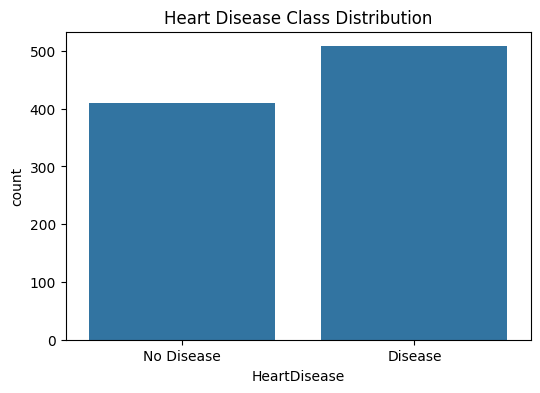

Class Distribution Percentage:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [23]:
# Visualize target class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=data)
plt.title("Heart Disease Class Distribution")
plt.xticks([0,1], ["No Disease","Disease"])
plt.show()

# Display class distribution percentage
print("Class Distribution Percentage:")
print(data['HeartDisease'].value_counts(normalize=True)*100)

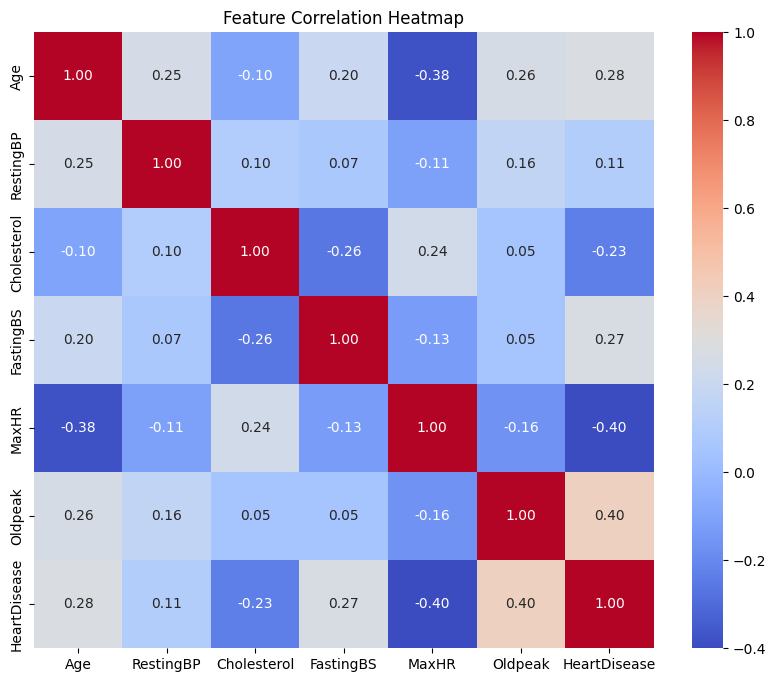

In [25]:
# Correlation Heatmap (only numerical features)
plt.figure(figsize=(10,8))

numeric_data = data.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Data Preprocessing

In [27]:
# Remove unrealistic cholesterol values
data = data[data['Cholesterol'] > 0]

print("Dataset shape after removing invalid cholesterol values:", data.shape)

Dataset shape after removing invalid cholesterol values: (746, 12)


In [29]:
# Remove rows with missing values
data = data.dropna()

print("Original shape:", data.shape)
print("After removing missing values:", data.shape)

Original shape: (746, 12)
After removing missing values: (746, 12)


In [31]:
# Detect and remove outliers using IQR
numerical_features = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
for col in numerical_features:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]

print("Dataset shape after removing outliers:", data.shape)

Dataset shape after removing outliers: (692, 12)


In [33]:
# Separate input features and target variable
X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (692, 11)
Target vector shape: (692,)


In [35]:
# Identify categorical columns for CatBoost
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Categorical Columns:", categorical_cols)

Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [37]:
# Identify numerical features
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

# Identify categorical features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", numerical_cols)
print("Categorical Features:", categorical_cols)

Numerical Features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical Features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [ ]:
# Model Training with CatBoost

In [39]:
# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (553, 11)
Testing set: (139, 11)


In [41]:
# Train CatBoost classifier
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=100
)

model.fit(X_train, y_train, cat_features=categorical_cols)

0:	learn: 0.8318264	total: 202ms	remaining: 1m 40s
100:	learn: 0.9439421	total: 4.76s	remaining: 18.8s
200:	learn: 0.9764919	total: 10.5s	remaining: 15.6s
300:	learn: 0.9891501	total: 16.1s	remaining: 10.6s
400:	learn: 0.9945750	total: 21.5s	remaining: 5.3s
499:	learn: 1.0000000	total: 27.3s	remaining: 0us


In [45]:
# Predict on test data
y_pred = model.predict(X_test)

In [ ]:
# Model Evaluation

In [47]:
# Perform hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

param_grid = {
    'depth': [4,6,8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 400, 600]
}

grid = GridSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train, cat_features=categorical_cols)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

# Optimized prediction
y_pred_best = best_model.predict(X_test)

Best Parameters: {'depth': 4, 'iterations': 600, 'learning_rate': 0.05}


In [49]:
# Evaluate model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("Model Performance:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model Performance:
Accuracy : 0.8848920863309353
Precision: 0.8636363636363636
Recall   : 0.890625
F1 Score : 0.8769230769230769


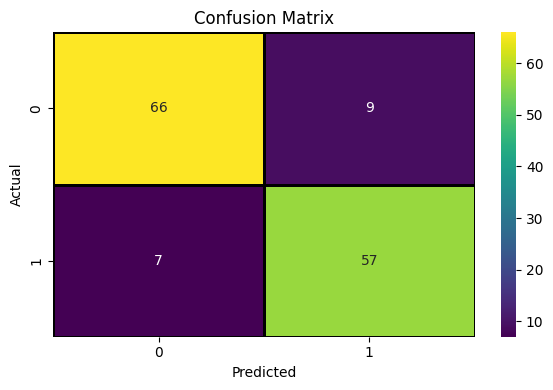

In [51]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    linewidths=1,
    linecolor='black'
)

# Labels and title
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [53]:
# Display classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        75
           1       0.86      0.89      0.88        64

    accuracy                           0.88       139
   macro avg       0.88      0.89      0.88       139
weighted avg       0.89      0.88      0.88       139



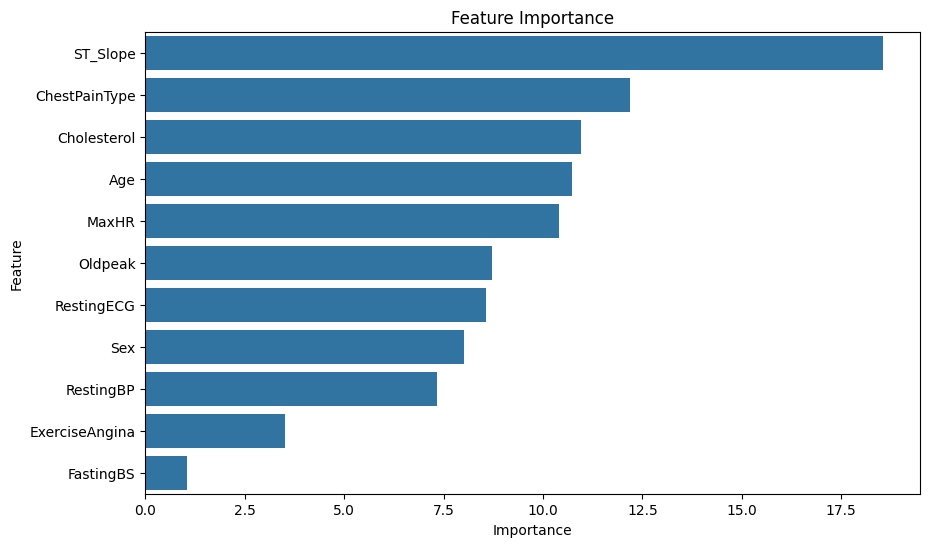

In [55]:
# Plot feature importance
importance = best_model.get_feature_importance()

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("Feature Importance")
plt.show()

In [57]:
# Perform cross-validation to evaluate model stability
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    best_model,
    X,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    params={'cat_features': categorical_cols}
)

print("Cross-Validation Performance:")

print("CV Accuracy :", cv_results['test_accuracy'].mean())
print("CV Precision:", cv_results['test_precision'].mean())
print("CV Recall   :", cv_results['test_recall'].mean())
print("CV F1 Score :", cv_results['test_f1'].mean())

Cross-Validation Performance:
CV Accuracy : 0.8509957251590032
CV Precision: 0.8411692583732059
CV Recall   : 0.8375
CV F1 Score : 0.8369719097316345


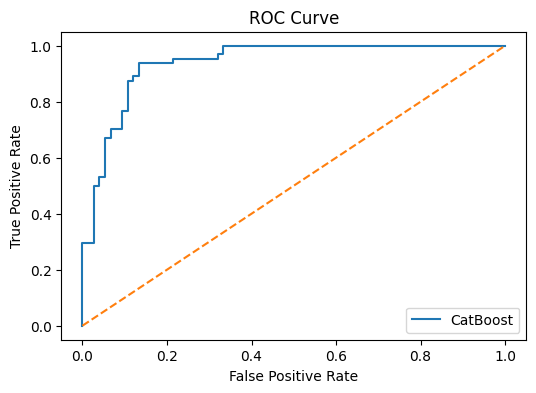

ROC-AUC Score: 0.9393750000000001


In [59]:
# Plot ROC Curve and calculate AUC score
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability predictions
y_prob = best_model.predict_proba(X_test)[:,1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="CatBoost")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Print AUC score
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [63]:
# Save the trained model
best_model.save_model('catboost_model.cbm')

print("Model saved successfully!")

Model saved successfully!
